# CIFAR-10 CNN
The goal of this model is to train on the CIFAR-10 dataset for image classification.  
The CIFAR-10 dataset contains 60000 images that are each 32x32 px in size.  
This model uses Convolutional Neural Networks (CNN). The notebook cifar-10_fcn builds a Fully Connected Neural Network (FCN).

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from tensorflow.keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

I0000 00:00:1774953483.982377    6833 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow


## Data preprocessing
Loads the CIFAR-10 dataset and prepares it for modeling.  
The training dataset has 50k values and the test set has 10k.

In [2]:
from tensorflow.keras.utils import to_categorical
# load the cifar-10 dataset and split it to train and test data.
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train, x_test = x_train / 255, x_test / 255
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(x_train.shape)
print(y_train.shape)

/home/juhana/anaconda3_v2/envs/keras/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3, 1)
(50000, 10)


## Building the model
I tried using BatchNormalization to optimize the model, but it only decreased results

In [3]:
from keras.layers import Input, Flatten, Dense, BatchNormalization
from keras import models

inputs = keras.Input(shape=(32, 32, 3))
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_model")

I0000 00:00:1774953488.907444    6833 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [5]:
history = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)

W0000 00:00:1774953491.131924    6833 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.
W0000 00:00:1774953491.875942    6833 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.


Epoch 1/10


I0000 00:00:1774953521.101793    6897 service.cc:153] XLA service 0x7a5454031180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774953521.101826    6897 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774953521.126374    6897 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774953493.034832    6897 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774953493.068784    6897 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1433__.34


  23/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1224 - loss: 2.2987

I0000 00:00:1774953497.279964    6897 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 152/1250 ━━━━━━━━━━━━━━━━━━━━ 3:29 191ms/step - accuracy: 0.1784 - loss: 2.2007

W0000 00:00:1774953501.136593    6833 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.
W0000 00:00:1774953501.341260    6833 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4262 - loss: 1.5863 - val_accuracy: 0.5342 - val_loss: 1.3350
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5440 - loss: 1.2902 - val_accuracy: 0.6035 - val_loss: 1.1579
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5896 - loss: 1.1756 - val_accuracy: 0.6181 - val_loss: 1.0930
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6128 - loss: 1.1082 - val_accuracy: 0.6532 - val_loss: 0.9974
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6319 - loss: 1.0542 - val_accuracy: 0.6442 - val_loss: 1.0419
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6450 - loss: 1.0240 - val_accuracy: 0.6694 - val_loss: 0.9575
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6553 - loss: 0.9926 - val_accuracy: 0.6808 - val_loss: 0.9276
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6651 - loss: 0.9658 - val_accura

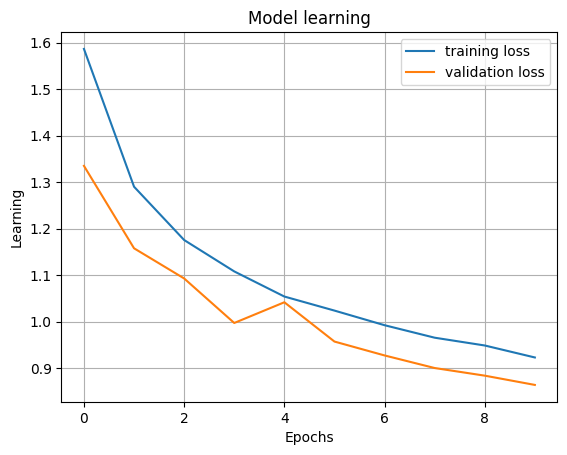

In [6]:
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Model learning")
plt.xlabel('Epochs')
plt.ylabel('Learning')
plt.legend()
plt.grid()
plt.show()

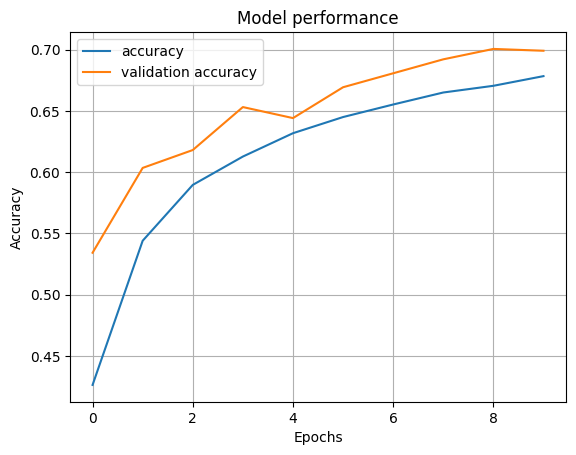

In [7]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Model performance")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

The model's performance is acceptable, though there are some minor signs of overfitting.

## Example images
![Raven image](img/raven.jpg) ✔ This picture depicts a raven and is correctly identified as a bird  

![Ostrich image](img/ostrich.jpg) ✔ This picture depicts an ostrich and is correctly labeled as a bird  

![Zebra image](img/zebra.jpg) 🔹 This picture depicts a zebra and is identified as a deer

![Stealth jet image](img/stealth_jet.jpg) ✔ This picture depicts a stealth jet and is correctly identified as an airplane  

![Monster truck image](img/monster_truck.jpg) ✔ This picture depicts a monster truck and is correctly identified as a truck

In [8]:
# img preprocessing and loading from geeksforgeeks / ChatGPT.
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

def load_and_process_image(name):
    img = load_img(f'img/{name}')
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [9]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def predict_image(img_array, name):
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    print(f"Image {name} is predicted to be {predicted_label}")
    return predictions[0]

In [10]:
probs1 = predict_image(load_and_process_image('raven.jpg'), 'Raven')
probs2 = predict_image(load_and_process_image('ostrich.jpg'), 'Ostrich')
probs3 = predict_image(load_and_process_image('zebra.jpg'), 'Zebra')
probs4 = predict_image(load_and_process_image('stealth_jet.jpg'), 'Stealth Jet')
probs5 = predict_image(load_and_process_image('monster_truck.jpg'), 'Monster Truck')

Image Raven is predicted to be bird
Image Ostrich is predicted to be bird
Image Zebra is predicted to be deer
Image Stealth Jet is predicted to be airplane
Image Monster Truck is predicted to be automobile


### Probability distributions per image

/tmp/ipykernel_6833/1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
/tmp/ipykernel_6833/1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
/tmp/ipykernel_6833/1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
/tmp/ipykernel_6833/1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
/tmp/ipykernel_6833/1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usin

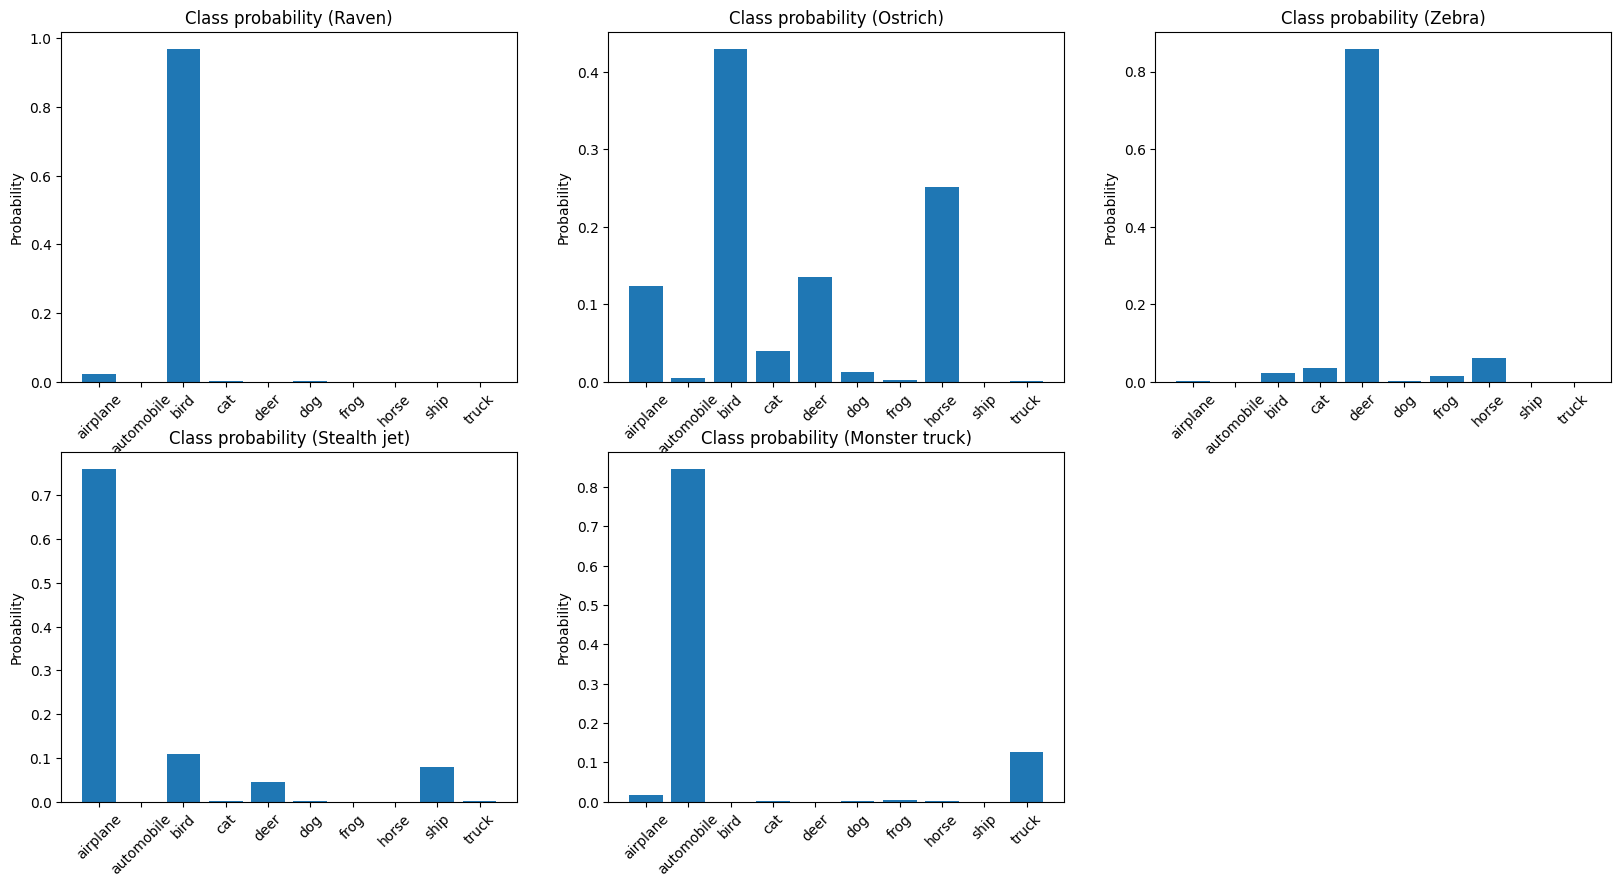

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [11]:
import math
all_probs = [probs1, probs2, probs3, probs4, probs5]
all_names = ["Raven", "Ostrich", "Zebra", "Stealth jet", "Monster truck"]

n_items = len(all_probs)
n_cols = 3
n_rows = math.ceil(n_items / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, probs in enumerate(all_probs):
    plt.figure()
    ax = axes[i]
    ax.bar(class_names, probs)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_ylabel("Probability")
    ax.set_title(f"Class probability ({all_names[i]})")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [12]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"The model's test accuracy is {acc}")

W0000 00:00:1774953548.009278    6833 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


The model's test accuracy is 0.7001000046730042


This model is significantly more accurate than the FCN model, though it still lands below the desired accuracy of 75% with a score of ~70%.  
The zebra is an interesting example image, because the CIFAR-10 dataset does not have a classification for it, and so the models  
flip-flop between deer and horse, with the CNN model settling on deer and the FCN model choosing horse.  
Overall, this model is clearly much more suited for the given task than the FCN model.